In [35]:
import cv2 as cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

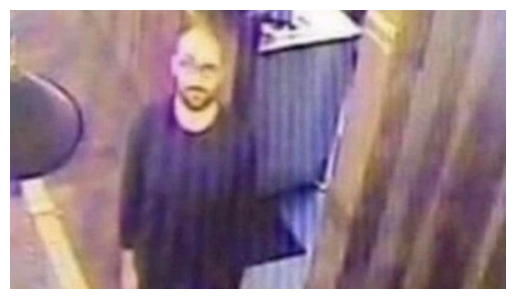

In [36]:
backup = cv2.imread('backup.jpg')
backup = cv2.cvtColor(backup, cv2.COLOR_RGB2BGR)
plt.imshow(backup)
plt.axis('off')
plt.show()

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

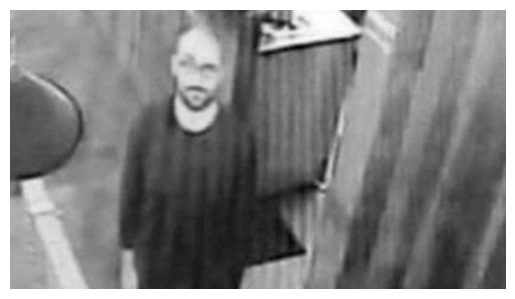

In [37]:
backup_gray = cv2.cvtColor(backup, cv2.COLOR_RGB2GRAY)
plt.imshow (backup_gray, cmap= 'gray')
plt.axis("off")

In [38]:
def filter(img, size, mode):
    height, width = img.shape

    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros((height, width), dtype=np.float32)

    match mode:
        case 'mean':
            area = size * size

            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]

                    total = 0
                    for row in region:
                        for val in row:
                            total += int(val)

                    mean_val = total / area
                    canvas[i, j] = mean_val

        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]

                    values = region.ravel().tolist()
                    values.sort()

                    mid = len(values) // 2
                    median_val = values[mid]

                    canvas[i, j] = median_val

        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]

                    values = region.ravel()

                    count = {}
                    for val in values:
                        val = int(val)
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1

                    max_count = 0
                    mode_val = 0

                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val

                    canvas[i, j] = mode_val

        case _:
            raise ValueError("Mode harus 'mean', 'median', atau 'modus'.")
    return np.clip(canvas, 0, 255).astype(np.uint8)

In [39]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

In [40]:
# kernel penghalus gambar / image smoothing kernel
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
], dtype=np.float32)

# kernel penajam gambar / image sharpening kernel
kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
], dtype=np.float32)

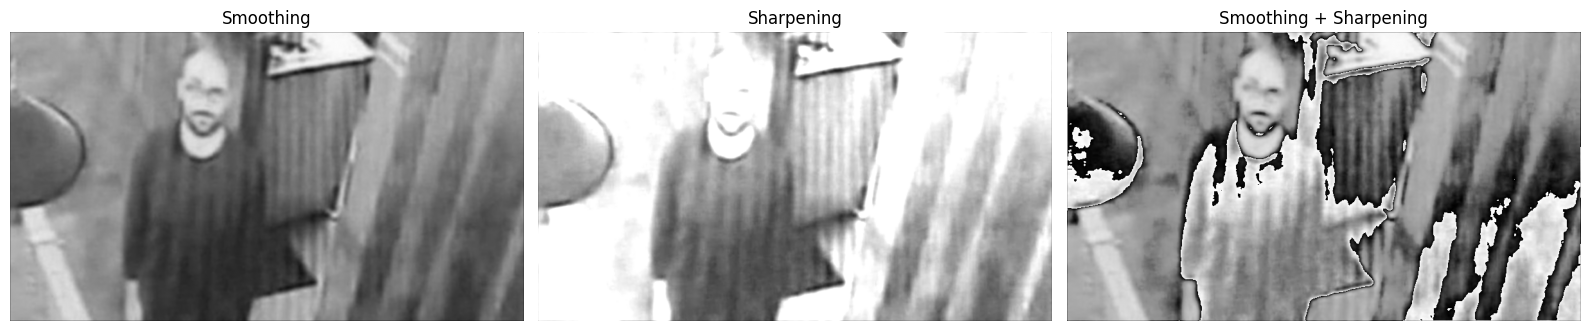

In [70]:
backup_gray = backup_gray.astype(np.uint8)
# Smoothing
smoothed = convolution(backup_gray, kernelSmoothing)
smoothed = np.clip(smoothed, 0, 255).astype(np.uint8)

# Sharpening
sharpened = convolution(backup_gray, kernelSharpening)
sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

#sharpe+smooth
smoothsharp = convolution(backup_gray, kernelSharpening)
smoothsharp = np.clip(sharpened, 0, 255).astype(np.uint8)
plt.figure(figsize=(16, 8))


plt.subplot(1, 3, 1)
plt.imshow(smoothed, cmap='gray', vmin=0, vmax=255)
plt.title('Smoothing')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sharpened, cmap='gray', vmin=0, vmax=255)
plt.title('Sharpening')
plt.axis('off')

#sharpe+smooth
smoothsharp = smoothed + sharpened

plt.subplot(1,3,3)
plt.imshow(smoothsharp, cmap='gray', vmin=0, vmax=255)
plt.title('Smoothing + Sharpening')
plt.axis('off')

plt.tight_layout()
plt.show()

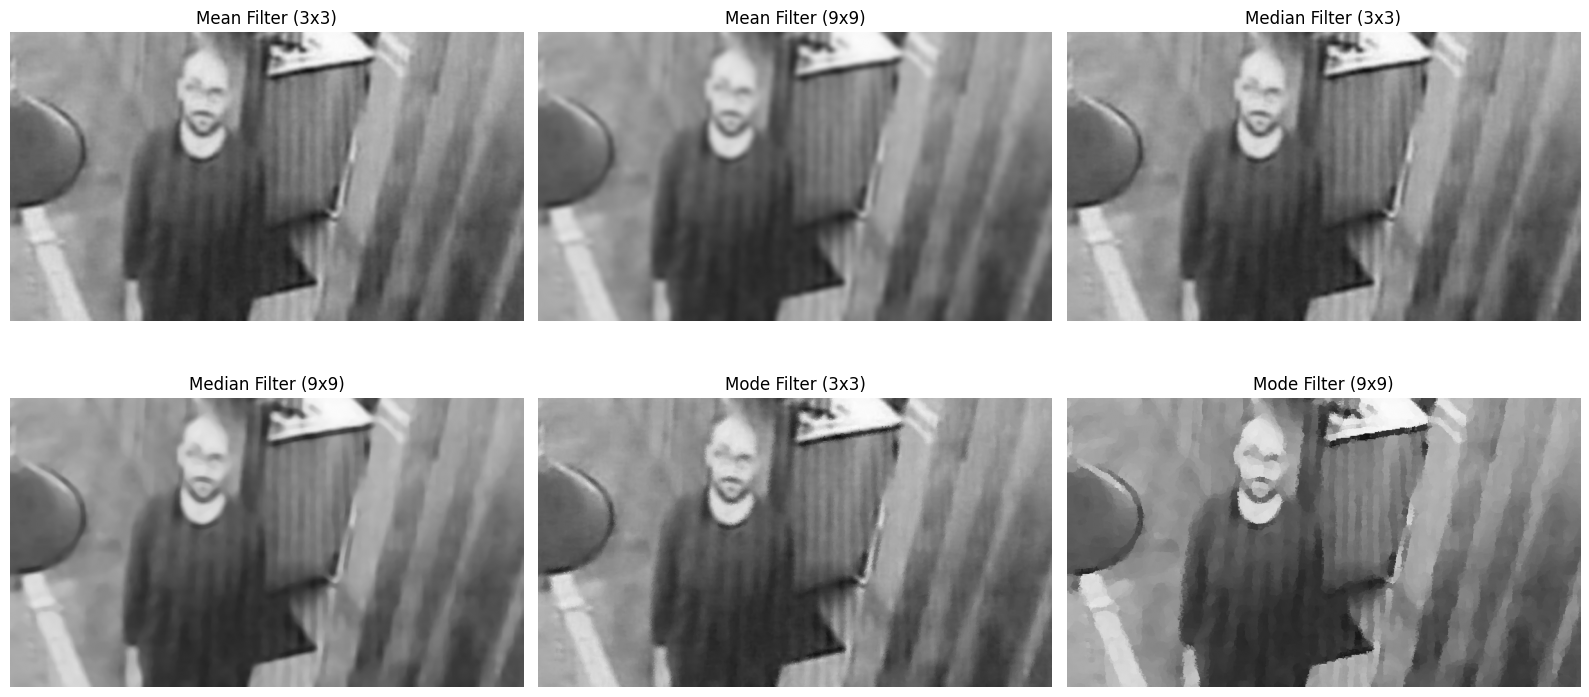

In [49]:
# Mean Filter
mean_3x3 = filter(backup_gray, 3, 'mean')
mean_9x9 = filter(backup_gray, 9, 'mean')

# Median Filter
median_3x3 = filter(backup_gray, 3, 'median')
median_9x9 = filter(backup_gray, 9, 'median')

# Modus Filter
mode_3x3 = filter(backup_gray, 3, 'modus')
mode_9x9 = filter(backup_gray, 9, 'modus')

plt.figure(figsize=(16, 8))
# Baris 1
plt.subplot(2, 3, 1)
plt.imshow(mean_3x3, cmap='gray', vmin=0, vmax=255)
plt.title('Mean Filter (3x3)')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(mean_9x9, cmap='gray', vmin=0, vmax=255)
plt.title('Mean Filter (9x9)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(median_3x3, cmap='gray', vmin=0, vmax=255)
plt.title('Median Filter (3x3)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(median_9x9, cmap='gray', vmin=0, vmax=255)
plt.title('Median Filter (9x9)')
plt.axis('off')

# Baris 2
plt.subplot(2, 3, 5)
plt.imshow(mode_3x3, cmap='gray', vmin=0, vmax=255)
plt.title('Mode Filter (3x3)')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(mode_9x9, cmap='gray', vmin=0, vmax=255)
plt.title('Mode Filter (9x9)')
plt.axis('off')

plt.tight_layout()
plt.show()

In [43]:
#kernel sobel sumbu x / x-axis sobel kernel
kernelSobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

#kernel sobel sumbu y / y-axis sobel kernel
kernelSobelY = np.array([
    [1, 2, 1],
    [ 0,  0,  0],
    [ -1,  -2,  -1]
], dtype=np.float32)

In [44]:
# kernel prewitt sumbu x / x-axis prewitt kernel
kernelPrewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

# kernel prewitt sumbu y / y-axis prewitt kernel
kernelPrewittY = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

In [45]:
#kernel roberts sumbu x / x-axis roberts kernel
kernelRobertsX = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

#kernel roberts sumbu y / y-axis roberts kernel
kernelRobertsY = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

In [46]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)

    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    if np.max(canvas) != 0:
        canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

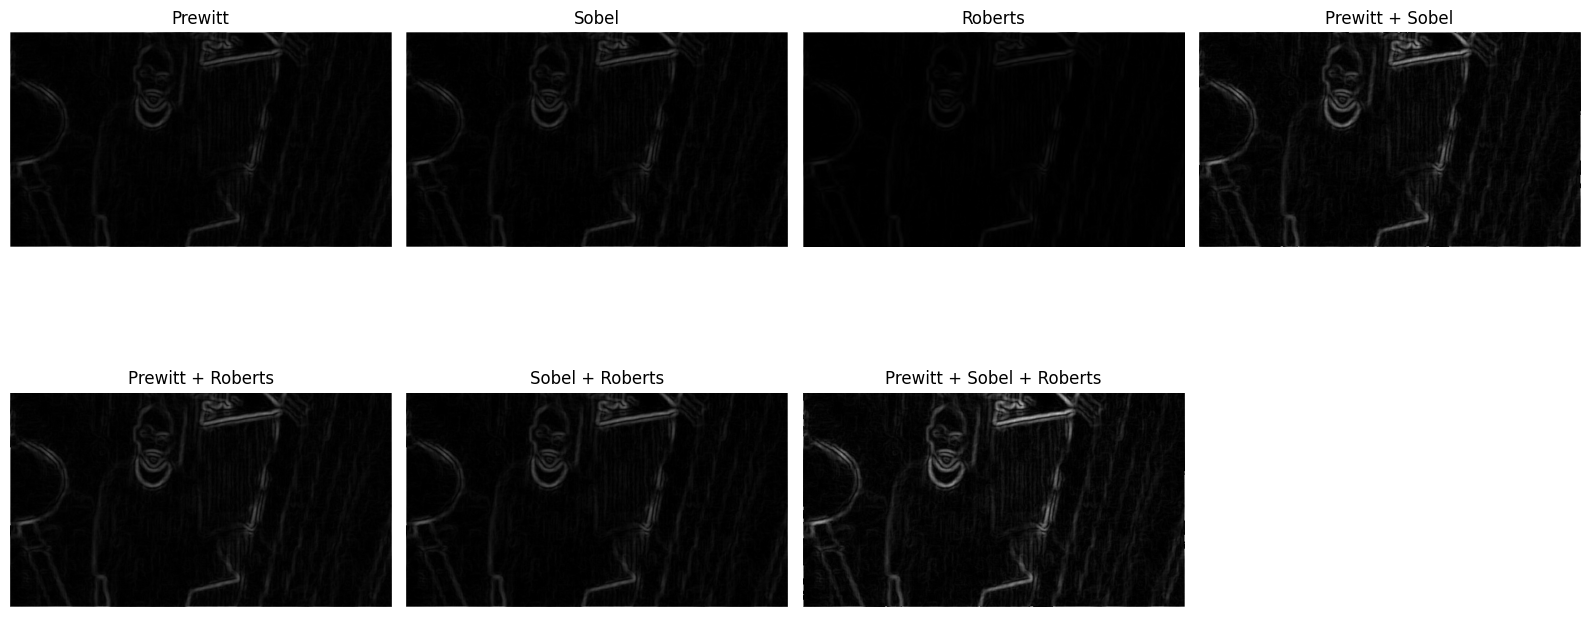

In [68]:
prewitt = edge(mean_3x3, kernelPrewittX, kernelPrewittY)
sobel = edge(mean_3x3, kernelSobelX, kernelSobelY)
roberts = edge(mean_3x3, kernelRobertsX, kernelRobertsY)

plt.figure(figsize=(16, 8))
plt.subplot(2,4,1)
plt.imshow(prewitt, cmap='gray', vmin=0, vmax=255)
plt.title('Prewitt')
plt.axis('off')

plt.subplot(2,4,2)
plt.imshow(sobel, cmap='gray', vmin=0, vmax=255)
plt.title('Sobel')
plt.axis('off')

plt.subplot(2,4,3)
plt.imshow(roberts, cmap='gray', vmin=0, vmax=255)
plt.title('Roberts')
plt.axis('off')

prewitt_sobel = prewitt + sobel
plt.subplot(2,4,4)
plt.imshow(prewitt_sobel, cmap='gray', vmin=0, vmax=255)
plt.title('Prewitt + Sobel')
plt.axis('off')

prewitt_roberts = prewitt + roberts
plt.subplot(2,4,5)
plt.imshow(prewitt_roberts, cmap='gray', vmin=0, vmax=255)
plt.title('Prewitt + Roberts')
plt.axis('off')

sobel_roberts = sobel + roberts
plt.subplot(2,4,6)
plt.imshow(sobel_roberts, cmap='gray', vmin=0, vmax=255)
plt.title('Sobel + Roberts')
plt.axis('off')

prewitt_sobel_roberts = prewitt + sobel + roberts
plt.subplot(2,4,7)
plt.imshow(prewitt_sobel_roberts, cmap='gray', vmin=0, vmax=255)
plt.title('Prewitt + Sobel + Roberts')
plt.axis('off')

plt.tight_layout()
plt.show()


In [78]:
def threshold(image, batas):
    hasil = np.copy(image)
    hasil[hasil>=batas] = 255
    hasil[hasil<batas] = 0
    return hasil

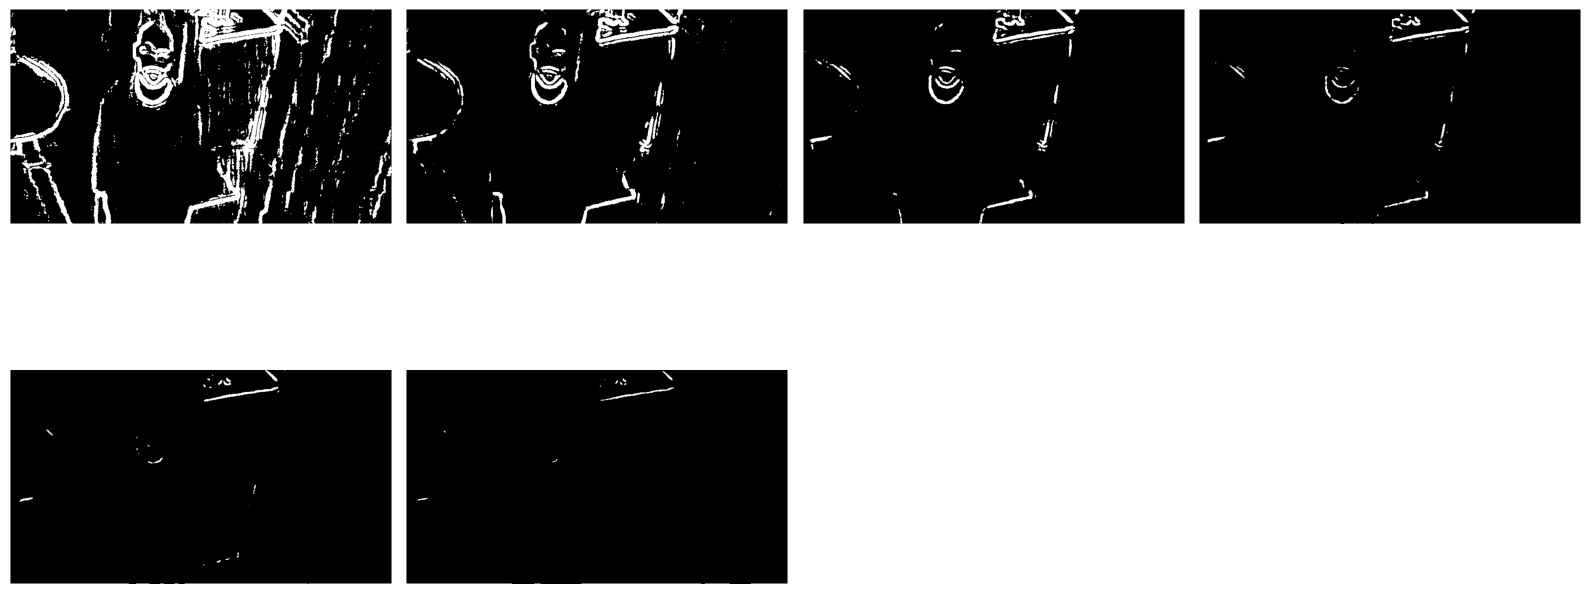

In [81]:
threshold10 = threshold(prewitt, 10)
threshold20 = threshold(prewitt, 20)
threshold30 = threshold(prewitt, 30)
threshold40 = threshold(prewitt, 40)
threshold50 = threshold(prewitt, 50)
threshold60 = threshold(prewitt, 60)

plt.figure(figsize=(16, 8))
plt.subplot(2,4,1)
plt.imshow(threshold10, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2,4,2)
plt.imshow(threshold20, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2,4,3)
plt.imshow(threshold30, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2,4,4)
plt.imshow(threshold40, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2,4,5)
plt.imshow(threshold50, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2,4,6)
plt.imshow(threshold60, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.tight_layout()
plt.show()

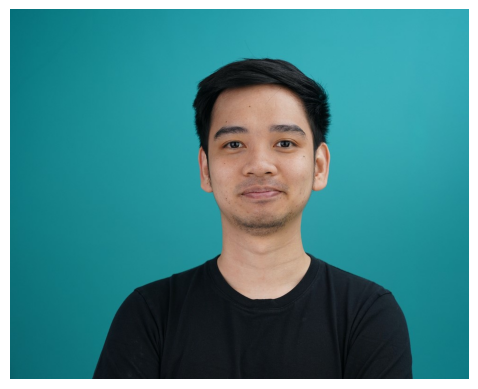

In [71]:
david = cv2.imread('david.jpg')
david = cv2.cvtColor(david, cv2.COLOR_RGB2BGR)
plt.imshow(david)
plt.axis('off')
plt.show()

(np.float64(-0.5), np.float64(977.5), np.float64(787.5), np.float64(-0.5))

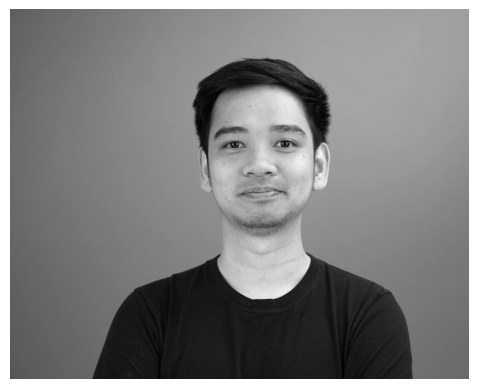

In [72]:
david_gray = cv2.cvtColor(david, cv2.COLOR_RGB2GRAY)
plt.imshow (david_gray, cmap= 'gray')
plt.axis("off")


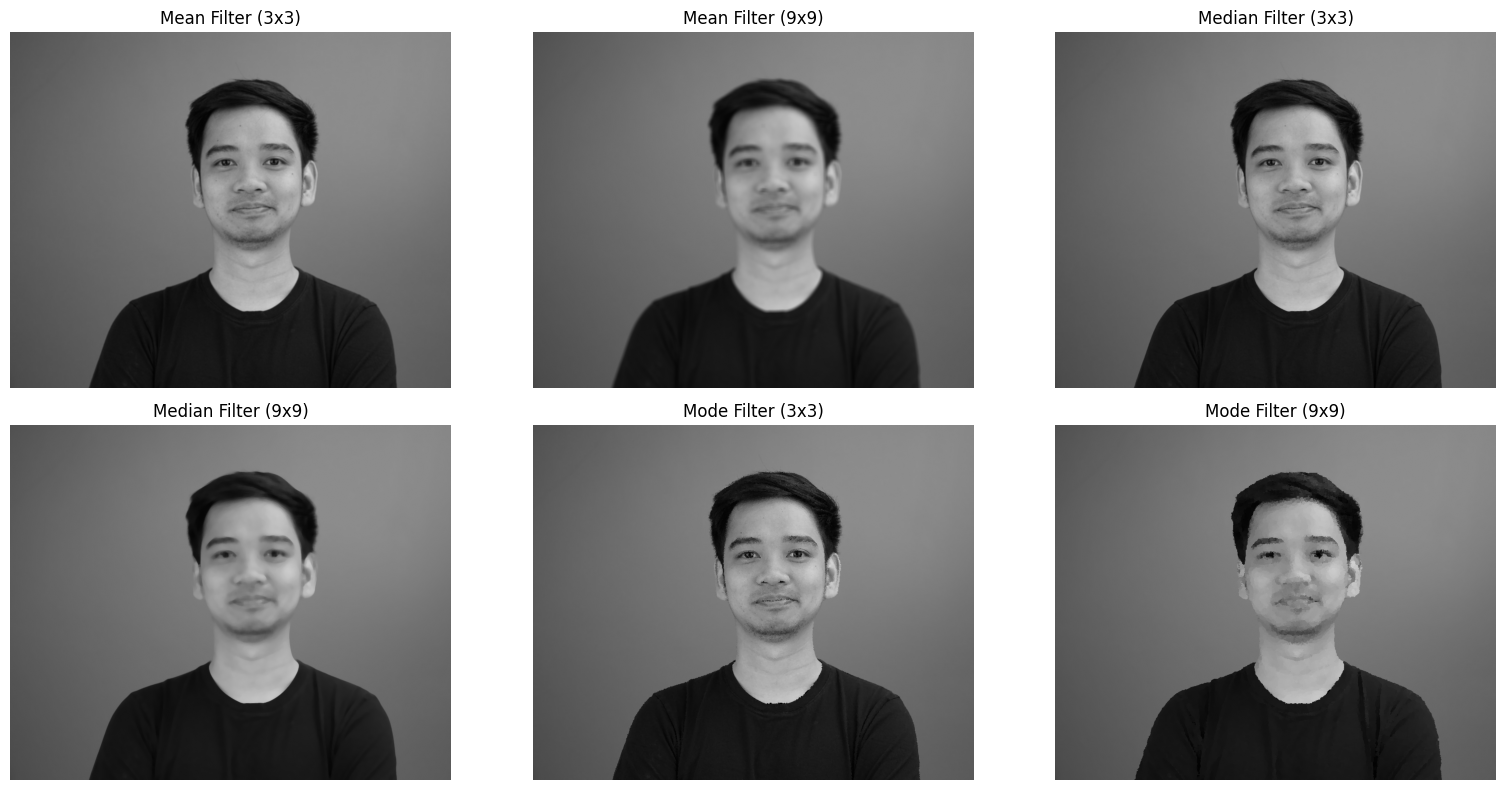

In [74]:
# Mean Filter
mean3x3 = filter(david_gray, 3, 'mean')
mean9x9 = filter(david_gray, 9, 'mean')

# Median Filter
median3x3 = filter(david_gray, 3, 'median')
median9x9 = filter(david_gray, 9, 'median')

# Modus Filter
mode3x3 = filter(david_gray, 3, 'modus')
mode9x9 = filter(david_gray, 9, 'modus')

plt.figure(figsize=(16, 8))
# Baris 1
plt.subplot(2, 3, 1)
plt.imshow(mean3x3, cmap='gray', vmin=0, vmax=255)
plt.title('Mean Filter (3x3)')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(mean9x9, cmap='gray', vmin=0, vmax=255)
plt.title('Mean Filter (9x9)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(median3x3, cmap='gray', vmin=0, vmax=255)
plt.title('Median Filter (3x3)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(median9x9, cmap='gray', vmin=0, vmax=255)
plt.title('Median Filter (9x9)')
plt.axis('off')

# Baris 2
plt.subplot(2, 3, 5)
plt.imshow(mode3x3, cmap='gray', vmin=0, vmax=255)
plt.title('Mode Filter (3x3)')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(mode9x9, cmap='gray', vmin=0, vmax=255)
plt.title('Mode Filter (9x9)')
plt.axis('off')

plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(977.5), np.float64(787.5), np.float64(-0.5))

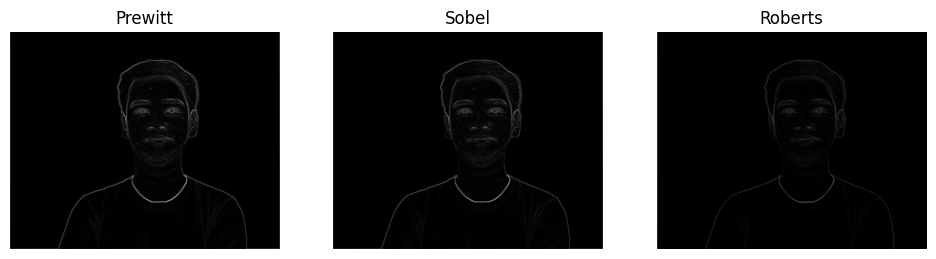

In [75]:
david_prewitt = edge(mean3x3, kernelPrewittX, kernelPrewittY)
david_sobel = edge(mean3x3, kernelSobelX, kernelSobelY)
david_roberts = edge(mean3x3, kernelRobertsX, kernelRobertsY)

plt.figure(figsize=(16, 8))
plt.subplot(2,4,1)
plt.imshow(david_prewitt, cmap='gray', vmin=0, vmax=255)
plt.title('Prewitt')
plt.axis('off')

plt.subplot(2,4,2)
plt.imshow(david_sobel, cmap='gray', vmin=0, vmax=255)
plt.title('Sobel')
plt.axis('off')

plt.subplot(2,4,3)
plt.imshow(david_roberts, cmap='gray', vmin=0, vmax=255)
plt.title('Roberts')
plt.axis('off')